In [2]:
import sys
sys.path.insert(0, "../src/fg_removal_pipe")  # add Folder_2 path to search list
import diff_removal as bss
from Jybeam_2_K import TFromJyBeam
#from power_spectrum import cyclindircal_powerspec
import astropy.io.fits as fits
import matplotlib.pyplot as plt
import numpy as np

base = '/home/ppxjf3/repos/Foreground_Removal_Pipeline/'

In [3]:
#open all fits images and make into numpy array

num = 12
init = 525
bss_data = np.zeros([1024,1024,num])
for ii in range(0,num):

    fits_path = base + 'data/ZW3_BSS_0'+str(init+ii)+'-image.fits'

    hdul = fits.open(fits_path)

    img = np.squeeze(hdul[0].data)
    bss_data[:,:,ii] = img
    hdul.info()
    hdul.close()

Filename: /home/ppxjf3/repos/Foreground_Removal_Pipeline/data/ZW3_BSS_0525-image.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      68   (1024, 1024, 1, 1)   float32   
Filename: /home/ppxjf3/repos/Foreground_Removal_Pipeline/data/ZW3_BSS_0526-image.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      68   (1024, 1024, 1, 1)   float32   
Filename: /home/ppxjf3/repos/Foreground_Removal_Pipeline/data/ZW3_BSS_0527-image.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      68   (1024, 1024, 1, 1)   float32   
Filename: /home/ppxjf3/repos/Foreground_Removal_Pipeline/data/ZW3_BSS_0528-image.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      68   (1024, 1024, 1, 1)   float32   
Filename: /home/ppxjf3/repos/Foreground_Removal_Pipeline/data/ZW3_BSS_0529-image.fits
No.    Name      Ver    Ty

In [4]:
#convert to K from Jy/beam
nu = np.arange(158.5, 158.5+num*0.1, 0.1)
print(nu)
#beam size
bmaj = 0.0441365996677112
bmin = 0.032916727852457

bss_data_K = TFromJyBeam(bss_data, bmaj, bmin, nu)

[158.5 158.6 158.7 158.8 158.9 159.  159.1 159.2 159.3 159.4 159.5 159.6]


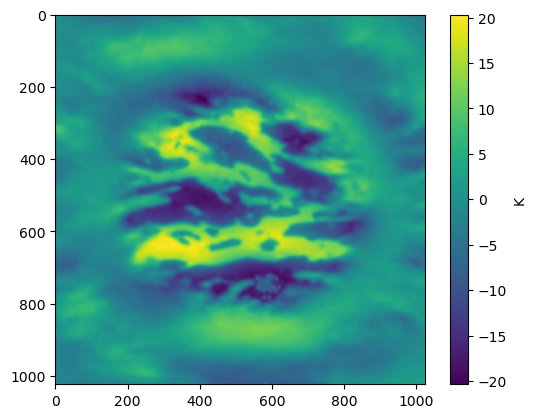

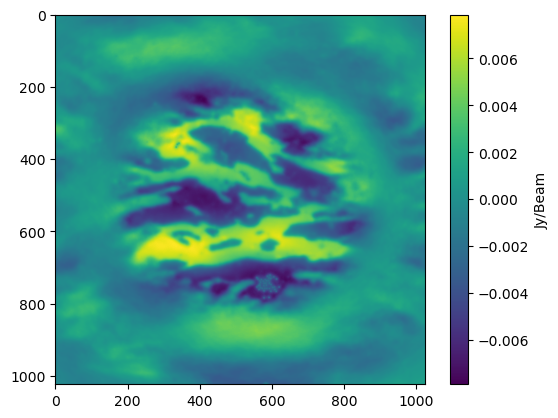

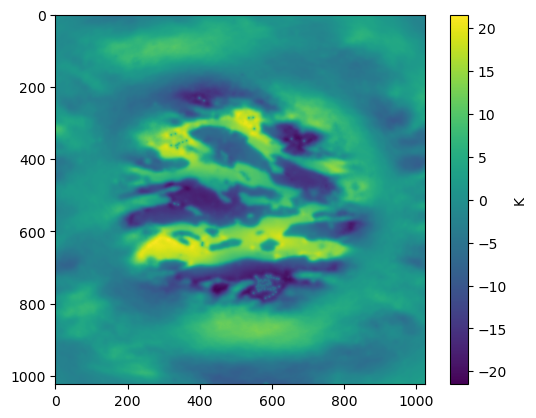

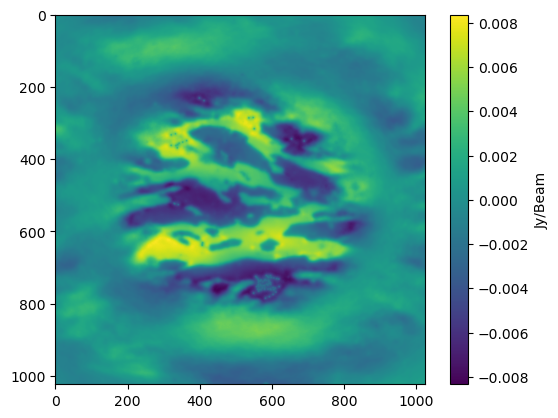

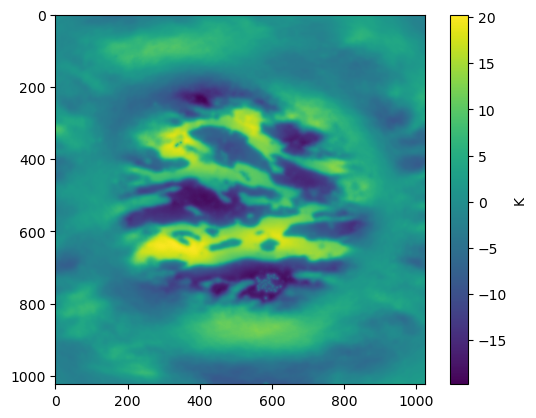

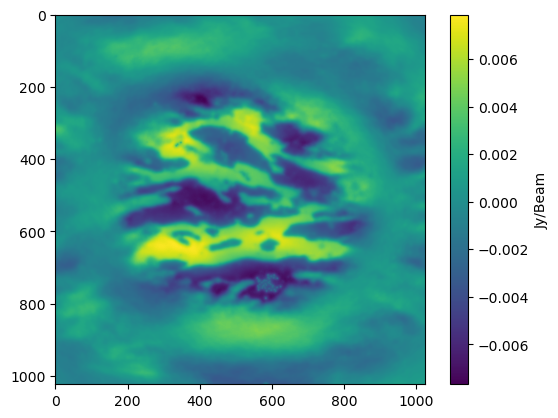

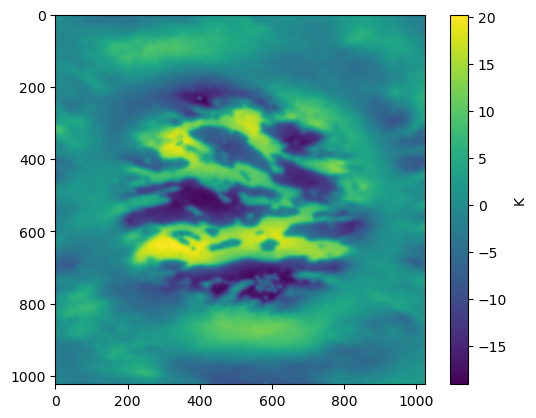

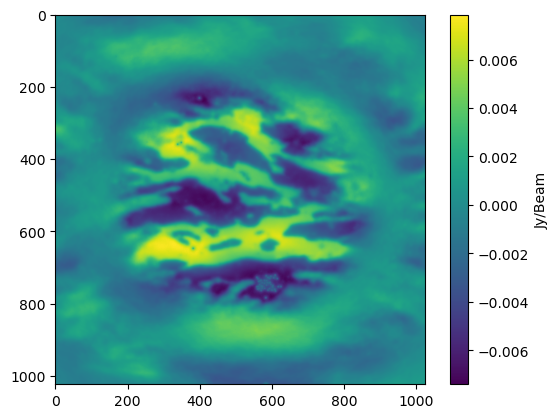

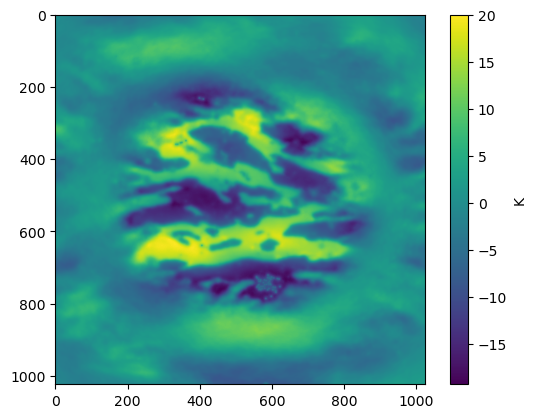

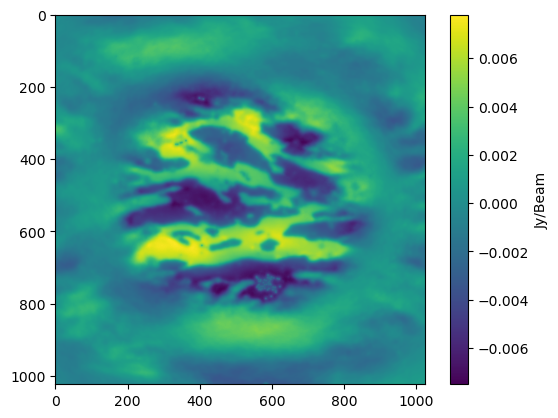

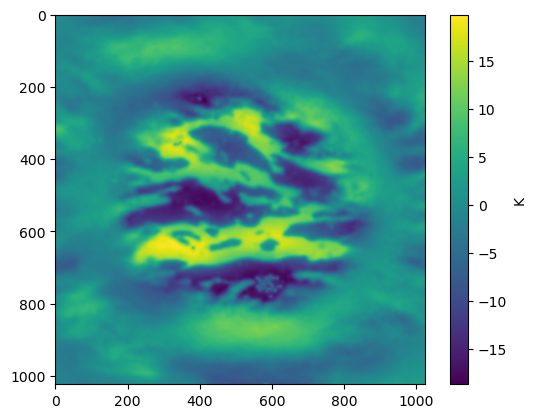

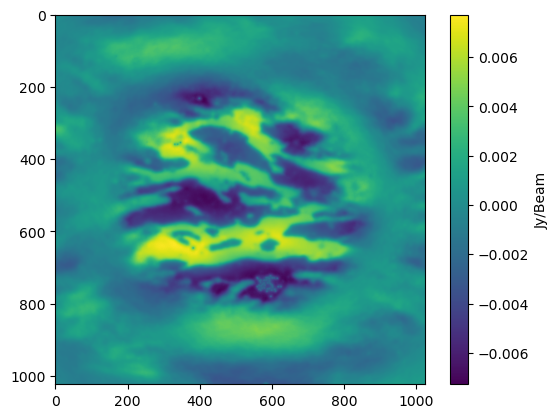

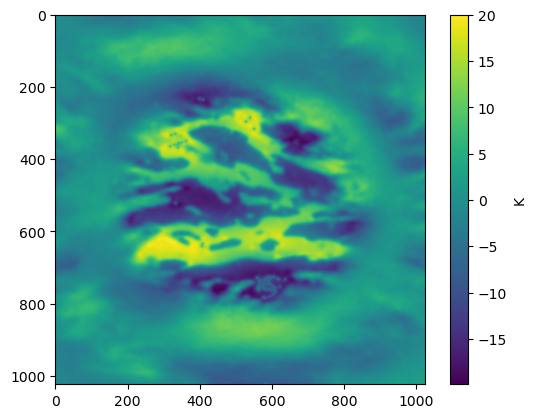

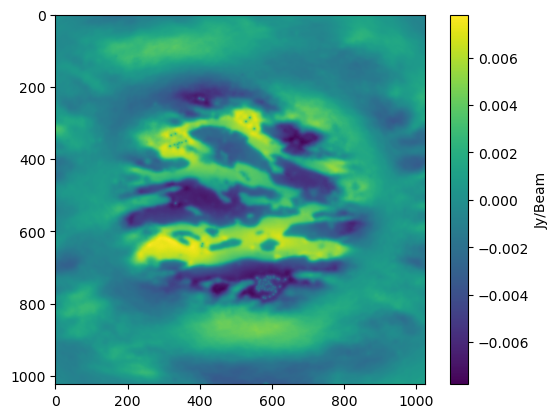

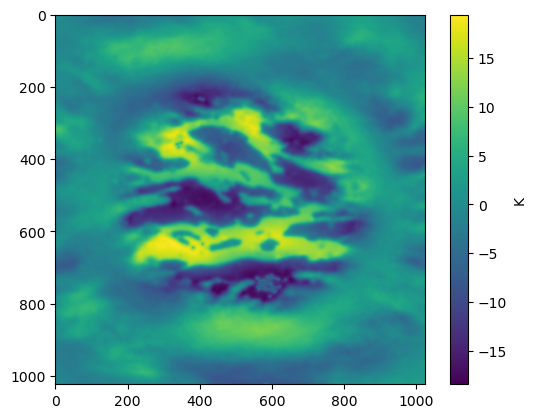

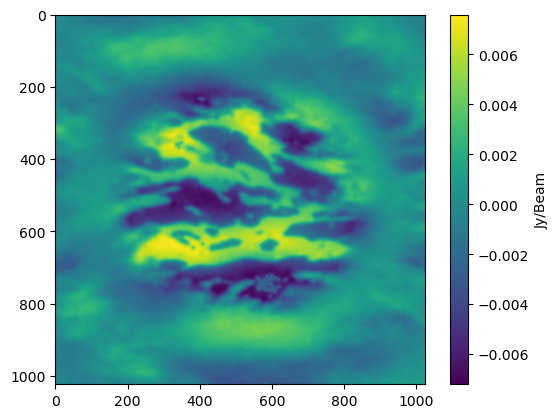

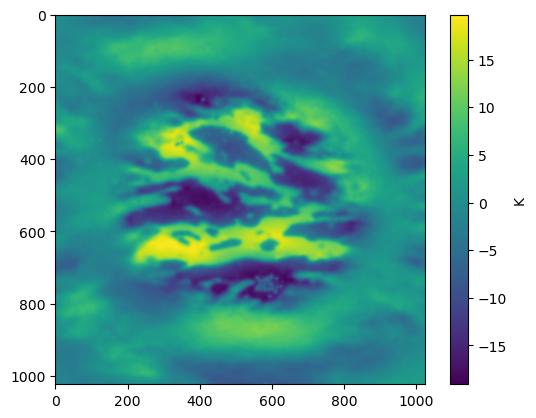

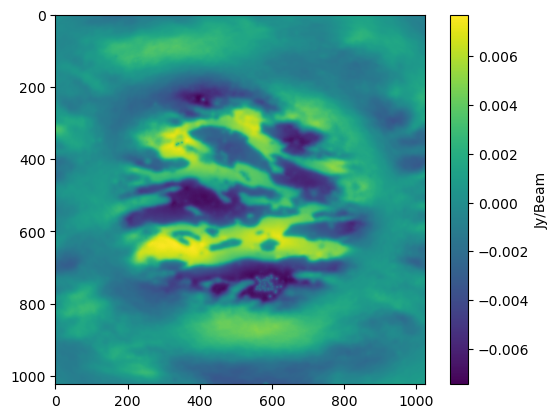

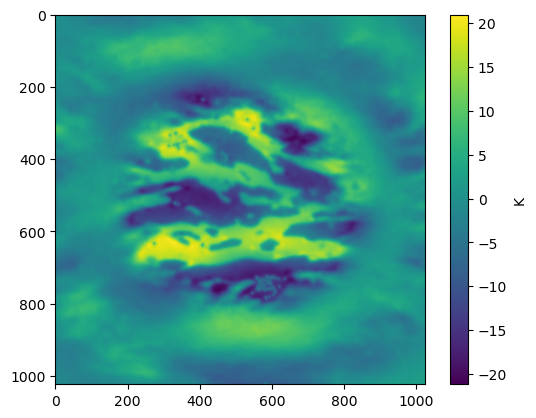

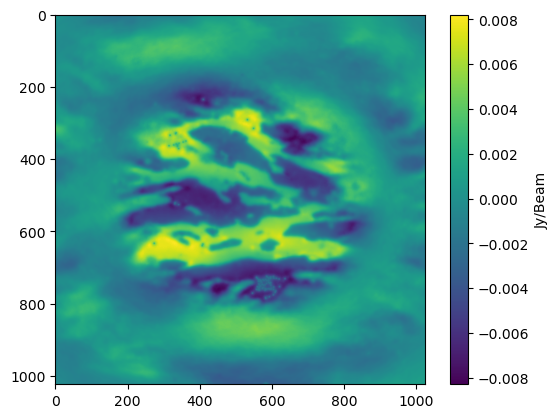

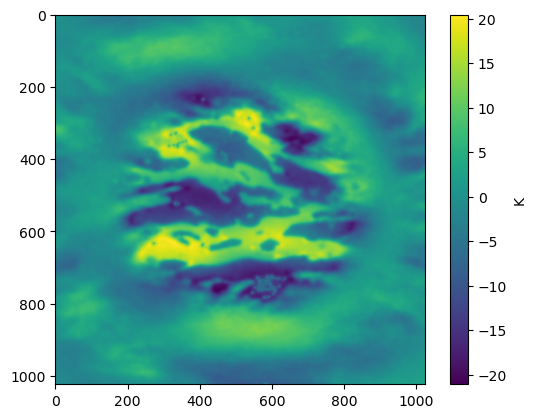

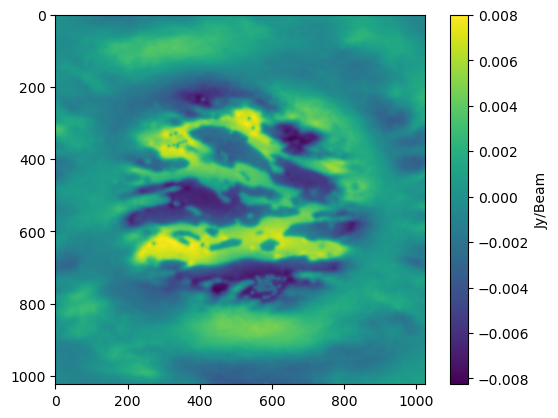

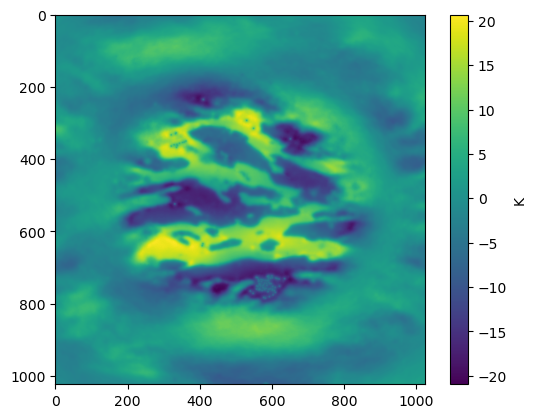

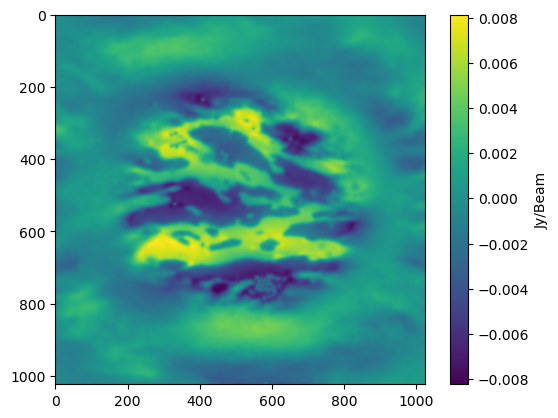

In [5]:
#look at images in K and Jy/beam
for ii in range(0,num):
    plt.imshow(bss_data_K[:,:,ii])
    plt.colorbar(label='K')
    plt.show()
    plt.imshow(bss_data[:,:,ii])
    plt.colorbar(label='Jy/Beam')
    plt.show()

In [6]:
#cut to central 4 degrees (512 by 512)
i0 = 512//2
i1 = 1024 - (512//2)

#FastICA
mod_fICA, res_fICA = bss.fastica(bss_data_K[i0:i1,i0:i1,:], 4)

#GPR
#mod_GPR, res_GPR = bss.GPR(bss_data_K[i0:i1,i0:i1,:], nu)  

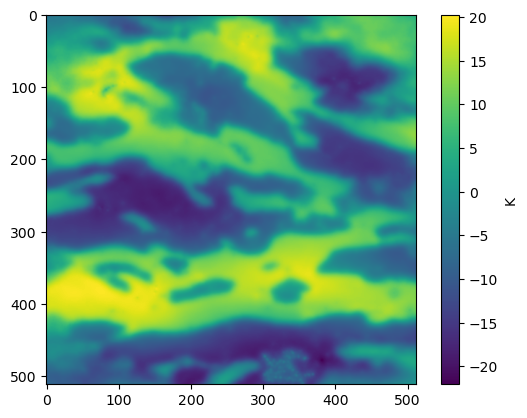

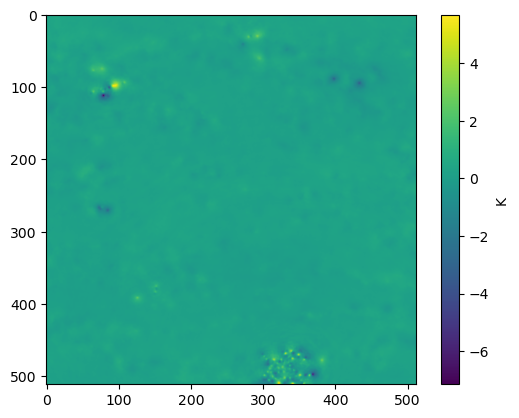

"plt.imshow(mod_GPR[:,:,0])\nplt.colorbar(label='K')\nplt.show()\nplt.imshow(res_GPR[:,:,0])\nplt.colorbar(label='K')\nplt.show()"

In [7]:
plt.imshow(mod_fICA[:,:,0])
plt.colorbar(label='K')
plt.show()
plt.imshow(res_fICA[:,:,0])
plt.colorbar(label='K')
plt.show()

"""plt.imshow(mod_GPR[:,:,0])
plt.colorbar(label='K')
plt.show()
plt.imshow(res_GPR[:,:,0])
plt.colorbar(label='K')
plt.show()"""

158.5
159.59999999999994
here
158.5
159.59999999999994
159.04999999999995


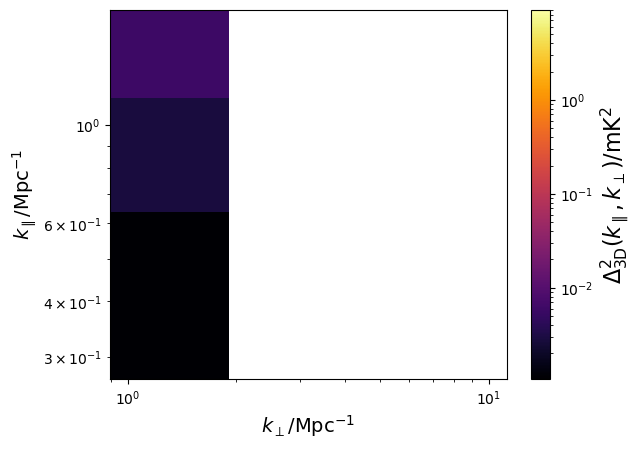

In [14]:
from power_spectrum import cyclindircal_powerspec


#make power spectra FastICA
plotting_scale={'x': 'log', 'y': 'log', 'z': 'log'}

kper, kpar, CC, norm = cyclindircal_powerspec(res_fICA, 3, nu, 4.0)

pcm = plt.pcolormesh(kper, kpar, CC, norm=norm, cmap='inferno')
cbar= plt.colorbar(pcm)
cbar.set_label(r'$\Delta_{\rm 3D}^2 (k_{\parallel}, k_{\perp}) /\rm mK^2 $', size=16) 
plt.xlabel(r'$k_{\perp}/ \rm Mpc^{-1}$', fontsize = 14)
plt.ylabel(r'$k_{\parallel} /\rm Mpc^{-1}$', fontsize = 14)
plt.xscale(plotting_scale['x'])
plt.yscale(plotting_scale['y'])
plt.show()

In [ ]:
#make power spectra GPR
plotting_scale={'x': 'log', 'y': 'log', 'z': 'log'}

kper, kpar, CC, norm = cyclindircal_powerspec()

pcm = plt.pcolormesh(kper, kpar, CC, norm=norm, cmap='inferno')
cbar= plt.colorbar(pcm)
cbar.set_label(r'$\Delta_{\rm 3D}^2 (k_{\parallel}, k_{\perp}) /\rm mK^2 $', size=16) 
plt.xlabel(r'$k_{\perp}/ \rm Mpc^{-1}$', fontsize = 14)
plt.ylabel(r'$k_{\parallel} /\rm Mpc^{-1}$', fontsize = 14)
plt.xscale(plotting_scale['x'])
plt.yscale(plotting_scale['y'])
plt.show()